IMPORTS

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns


from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.metrics import (
    accuracy_score, roc_auc_score, roc_curve,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.ensemble import (
    RandomForestClassifier, ExtraTreesClassifier,
    BaggingClassifier, GradientBoostingClassifier
)
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

try:
    import folium
    from folium.plugins import HeatMap
    FOLIUM_AVAILABLE = True
except ImportError:
    FOLIUM_AVAILABLE = False

sns.set_theme(style="whitegrid", palette="Set2")
tf.random.set_seed(42)
np.random.seed(42)

print("All libraries loaded.\n")

All libraries loaded.



 SECTION 1 – DATA INGESTION & INITIAL INSPECTION

In [ ]:
df = pd.read_csv('/content/Telco_customer_churn.csv')

print(f"Raw shape : {df.shape[0]:,} rows × {df.shape[1]} columns")
print("\nColumn dtypes:")


Raw shape : 7,043 rows × 33 columns

Column dtypes:


In [ ]:
print(df.dtypes.to_string())
print("\nDescriptive statistics:")


CustomerID            object
Count                  int64
Country               object
State                 object
City                  object
Zip Code               int64
Lat Long              object
Latitude             float64
Longitude            float64
Gender                object
Senior Citizen        object
Partner               object
Dependents            object
Tenure Months          int64
Phone Service         object
Multiple Lines        object
Internet Service      object
Online Security       object
Online Backup         object
Device Protection     object
Tech Support          object
Streaming TV          object
Streaming Movies      object
Contract              object
Paperless Billing     object
Payment Method        object
Monthly Charges      float64
Total Charges         object
Churn Label           object
Churn Value            int64
Churn Score            int64
CLTV                   int64
Churn Reason          object

Descriptive statistics:


In [ ]:
print(df.describe().round(2).to_string())
print("\nMissing values at load:")
missing = df.isnull().sum()
print(missing[missing > 0].to_string() if missing.sum() > 0 else "None")

        Count  Zip Code  Latitude  Longitude  Tenure Months  Monthly Charges  Churn Value  Churn Score     CLTV
count  7043.0   7043.00   7043.00    7043.00        7043.00          7043.00      7043.00      7043.00  7043.00
mean      1.0  93521.96     36.28    -119.80          32.37            64.76         0.27        58.70  4400.30
std       0.0   1865.79      2.46       2.16          24.56            30.09         0.44        21.53  1183.06
min       1.0  90001.00     32.56    -124.30           0.00            18.25         0.00         5.00  2003.00
25%       1.0  92102.00     34.03    -121.82           9.00            35.50         0.00        40.00  3469.00
50%       1.0  93552.00     36.39    -119.73          29.00            70.35         0.00        61.00  4527.00
75%       1.0  95351.00     38.22    -118.04          55.00            89.85         1.00        75.00  5380.50
max       1.0  96161.00     41.96    -114.19          72.00           118.75         1.00       100.00  

SECTION 2 – JUSTIFIED COLUMN REMOVAL

In [ ]:
# Unique identifiers, target-leakage columns, and zero-variance constants
cols_to_drop = {
    'Customer ID'  : 'Unique identifier – no predictive signal',
    'CustomerID'   : 'Unique identifier – no predictive signal',
    'Churn Label'  : 'Target leakage – text mirror of Churn Value',
    'Churn Score'  : 'Target leakage – post-hoc propensity score',
    'Churn Reason' : 'Target leakage – post-departure stated reason',
    'Count'        : 'Constant column – zero variance',
}

for col, reason in cols_to_drop.items():
    if col in df.columns:
        df.drop(columns=[col], inplace=True)
        print(f"  Dropped '{col}': {reason}")

print(f"\nShape after drops: {df.shape}")

  Dropped 'CustomerID': Unique identifier – no predictive signal
  Dropped 'Churn Label': Target leakage – text mirror of Churn Value
  Dropped 'Churn Score': Target leakage – post-hoc propensity score
  Dropped 'Churn Reason': Target leakage – post-departure stated reason
  Dropped 'Count': Constant column – zero variance

Shape after drops: (7043, 28)


SECTION 3 – MISSING VALUE HANDLING

In [ ]:
# Coerce Total Charges blanks to NaN then impute with column median
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')

if df['Total Charges'].isnull().sum() > 0:
    median_val = df['Total Charges'].median()
    n_missing  = df['Total Charges'].isnull().sum()
    df['Total Charges'].fillna(median_val, inplace=True)
    print(f"Imputed {n_missing} missing 'Total Charges' with median = {median_val:.2f}")

# Median imputation for any remaining numeric NaNs
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
df[num_cols] = SimpleImputer(strategy='median').fit_transform(df[num_cols])

# Mode imputation for any remaining categorical NaNs
for col in df.select_dtypes(include='object').columns:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].mode()[0], inplace=True)

print(f"Missing values after imputation: {df.isnull().sum().sum()}")



Imputed 11 missing 'Total Charges' with median = 1397.47
Missing values after imputation: 0


/tmp/ipykernel_1041/1881556282.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Total Charges'].fillna(median_val, inplace=True)


SECTION 4 – OUTLIER DETECTION (IQR METHOD)

In [ ]:
continuous_cols = ['Tenure Months', 'Monthly Charges', 'Total Charges', 'CLTV']
rows_to_drop    = set()

print(f"\n{'Column':<22} {'Q1':>7} {'Q3':>7} {'IQR':>7} {'Outliers':>8}")
print("-" * 55)

for col in continuous_cols:
    if col not in df.columns:
        continue
    Q1, Q3   = df[col].quantile([0.25, 0.75])
    IQR      = Q3 - Q1
    lower    = Q1 - 1.5 * IQR
    upper    = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)].index
    rows_to_drop.update(outliers)
    print(f"{col:<22} {Q1:>7.1f} {Q3:>7.1f} {IQR:>7.1f} {len(outliers):>8}")

df = df.drop(index=list(rows_to_drop))
print(f"\nOutliers removed : {len(rows_to_drop)}")
print(f"Shape after IQR  : {df.shape}")


Column                      Q1      Q3     IQR Outliers
-------------------------------------------------------
Tenure Months              9.0    55.0    46.0        0
Monthly Charges           35.5    89.8    54.3        0
Total Charges            402.2  3786.6  3384.4        0
CLTV                    3469.0  5380.5  1911.5        0

Outliers removed : 0
Shape after IQR  : (7043, 28)


 SECTION 5 – EXPLORATORY DATA ANALYSIS (PRE-BALANCING)

5a. Target variable distribution

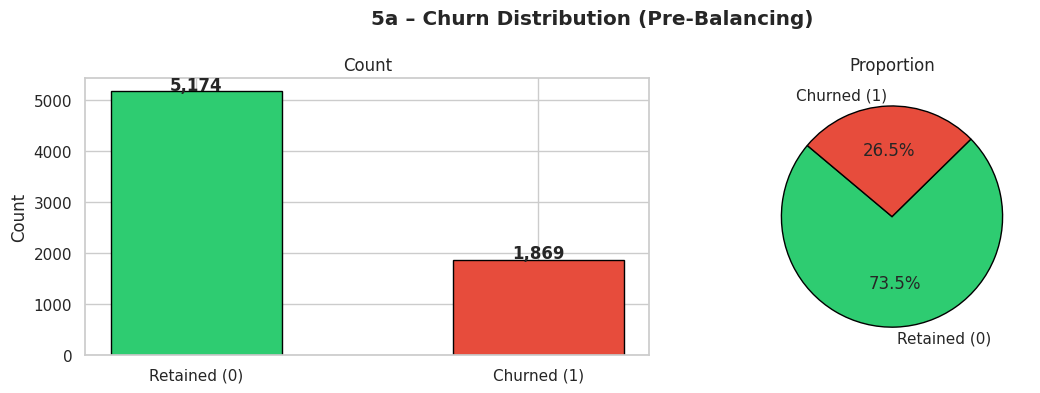

In [ ]:
churn_counts = df['Churn Value'].value_counts().sort_index()
labels       = ['Retained (0)', 'Churned (1)']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('5a – Churn Distribution (Pre-Balancing)', fontweight='bold')

axes[0].bar(labels, churn_counts.values, color=['#2ecc71', '#e74c3c'],
            edgecolor='black', width=0.5)
axes[0].set_title('Count')
axes[0].set_ylabel('Count')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 30, f'{v:,}', ha='center', fontweight='bold')

axes[1].pie(churn_counts.values, labels=labels, autopct='%1.1f%%',
            colors=['#2ecc71', '#e74c3c'], startangle=140,
            wedgeprops={'edgecolor': 'black'})
axes[1].set_title('Proportion')
plt.tight_layout()
plt.show()

5b. Numerical feature histograms by churn

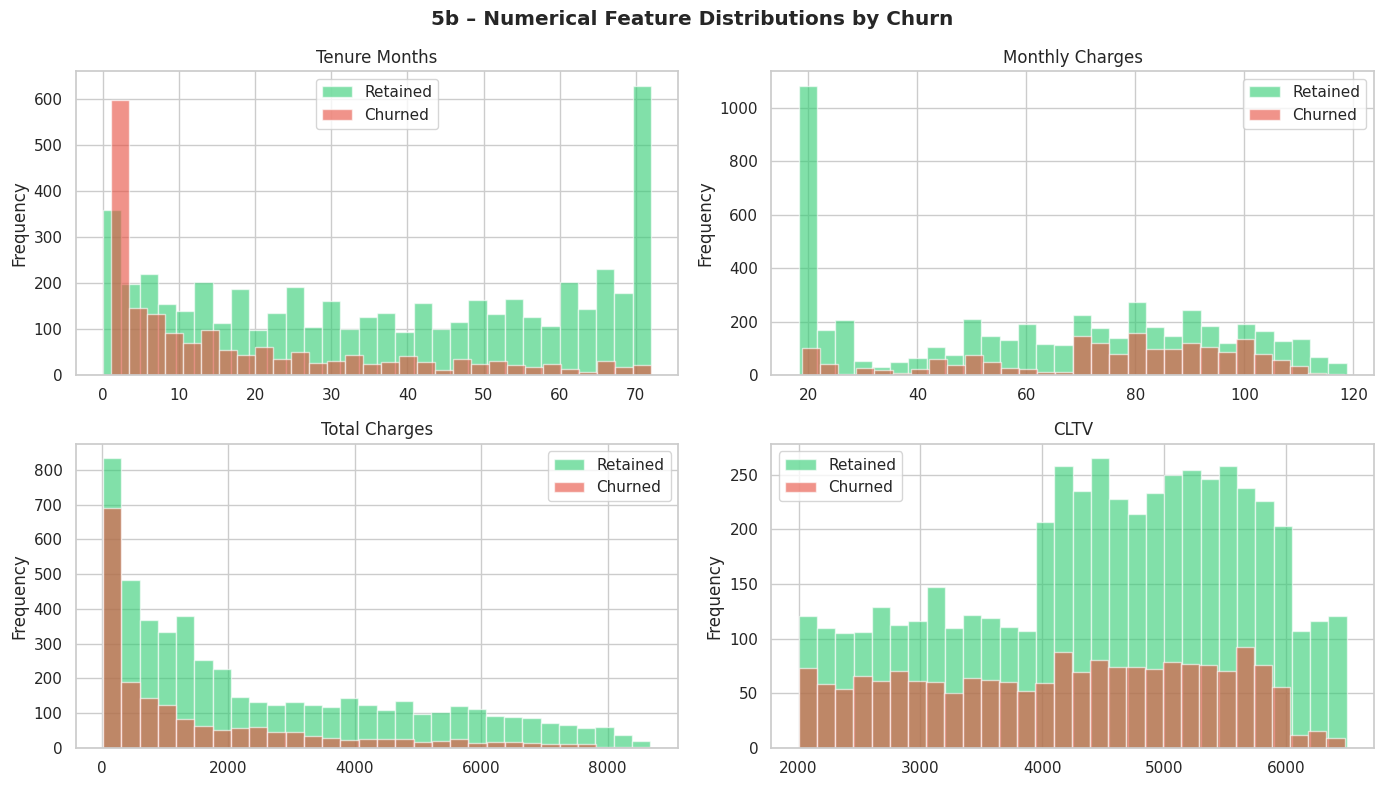

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('5b – Numerical Feature Distributions by Churn', fontweight='bold')

for ax, col in zip(axes.flatten(), continuous_cols):
    if col not in df.columns:
        continue
    for val, colour, label in [(0, '#2ecc71', 'Retained'), (1, '#e74c3c', 'Churned')]:
        ax.hist(df[df['Churn Value'] == val][col], bins=30, alpha=0.6,
                color=colour, label=label, edgecolor='white')
    ax.set_title(col)
    ax.set_ylabel('Frequency')
    ax.legend()
plt.tight_layout()
plt.show()

5c. Boxplots by churn class

/tmp/ipykernel_1041/3455619056.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_bp, patch_artist=True, labels=['Retained', 'Churned'],
/tmp/ipykernel_1041/3455619056.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_bp, patch_artist=True, labels=['Retained', 'Churned'],
/tmp/ipykernel_1041/3455619056.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_bp, patch_artist=True, labels=['Retained', 'Churned'],
/tmp/ipykernel_1041/3455619056.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotl

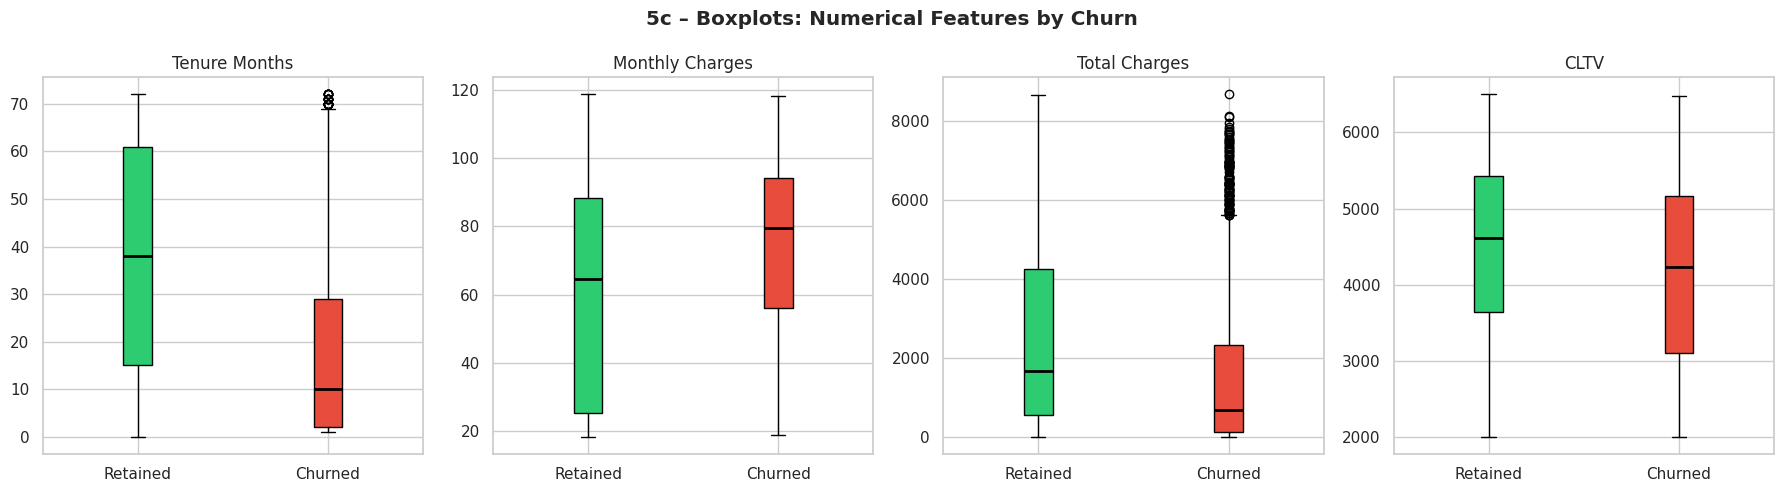

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle('5c – Boxplots: Numerical Features by Churn', fontweight='bold')

for ax, col in zip(axes, continuous_cols):
    if col not in df.columns:
        continue
    data_bp = [df[df['Churn Value'] == 0][col].dropna(),
               df[df['Churn Value'] == 1][col].dropna()]
    bp = ax.boxplot(data_bp, patch_artist=True, labels=['Retained', 'Churned'],
                    medianprops=dict(color='black', linewidth=2))
    bp['boxes'][0].set_facecolor('#2ecc71')
    bp['boxes'][1].set_facecolor('#e74c3c')
    ax.set_title(col)
plt.tight_layout()
plt.show()

5d. Categorical features vs churn rate

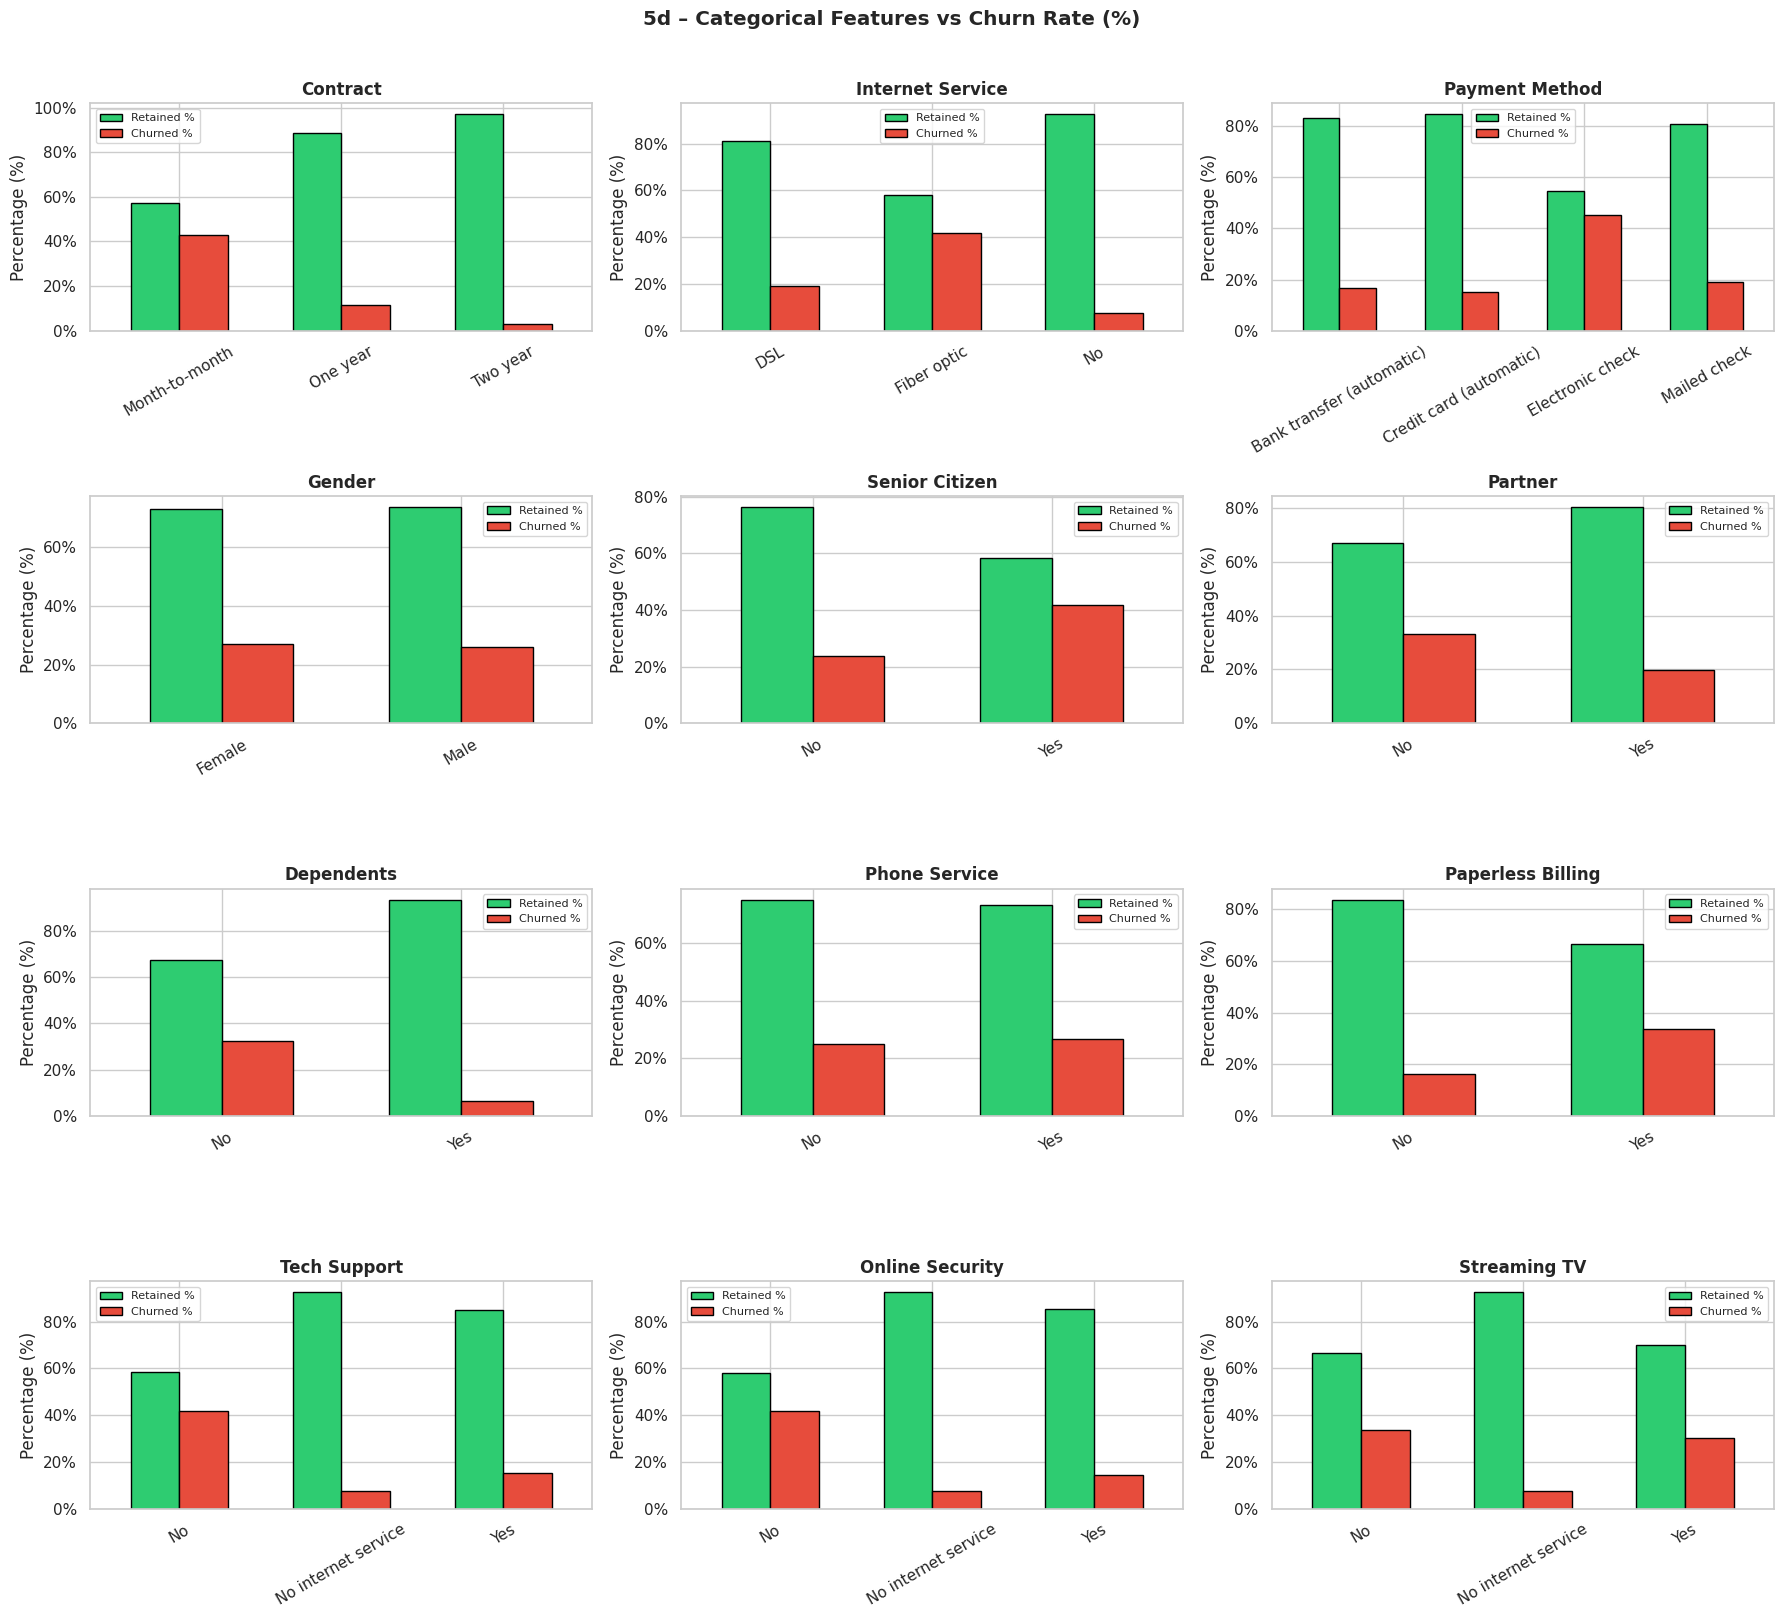

In [ ]:
cat_to_plot = [c for c in [
    'Contract', 'Internet Service', 'Payment Method', 'Gender',
    'Senior Citizen', 'Partner', 'Dependents', 'Phone Service',
    'Paperless Billing', 'Tech Support', 'Online Security', 'Streaming TV'
] if c in df.columns]

ncols = 3
nrows = (len(cat_to_plot) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 4))
fig.suptitle('5d – Categorical Features vs Churn Rate (%)', fontweight='bold', y=1.01)
axes = axes.flatten()

for i, col in enumerate(cat_to_plot):
    ct = pd.crosstab(df[col], df['Churn Value'], normalize='index') * 100
    ct.columns = ['Retained %', 'Churned %']
    ct.plot(kind='bar', ax=axes[i], color=['#2ecc71', '#e74c3c'],
            edgecolor='black', width=0.6)
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_ylabel('Percentage (%)')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].legend(fontsize=8)
    axes[i].yaxis.set_major_formatter(mticker.PercentFormatter())

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
plt.show()

5e. Correlation heatmap

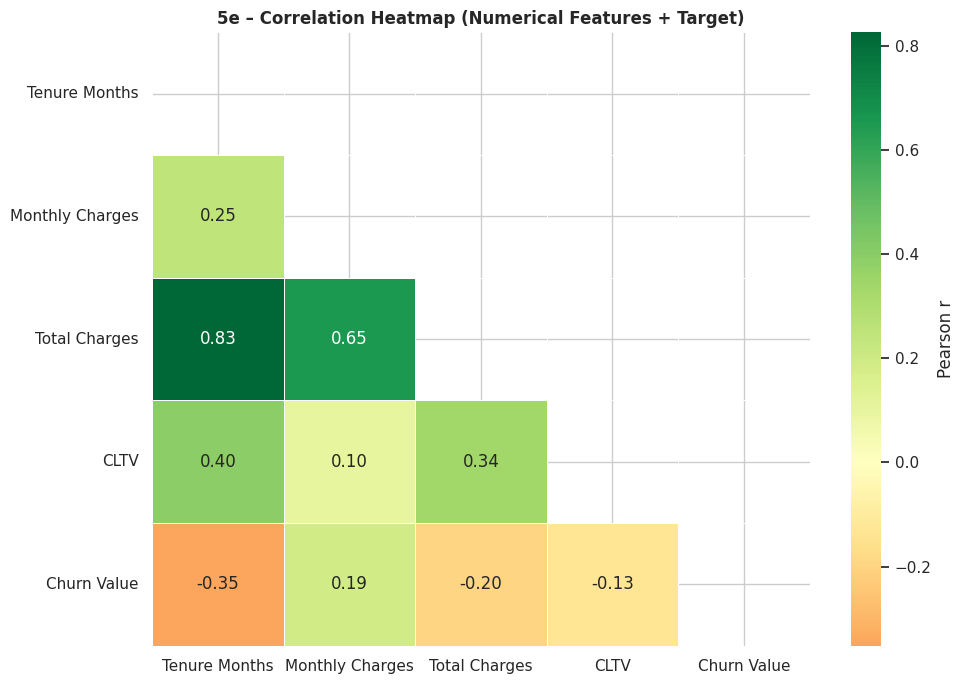

In [ ]:
corr_cols   = [c for c in continuous_cols + ['Churn Value'] if c in df.columns]
corr_matrix = df[corr_cols].corr()
mask        = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Pearson r'})
ax.set_title('5e – Correlation Heatmap (Numerical Features + Target)', fontweight='bold')
plt.tight_layout()
plt.show()

5f. Pairplot coloured by churn


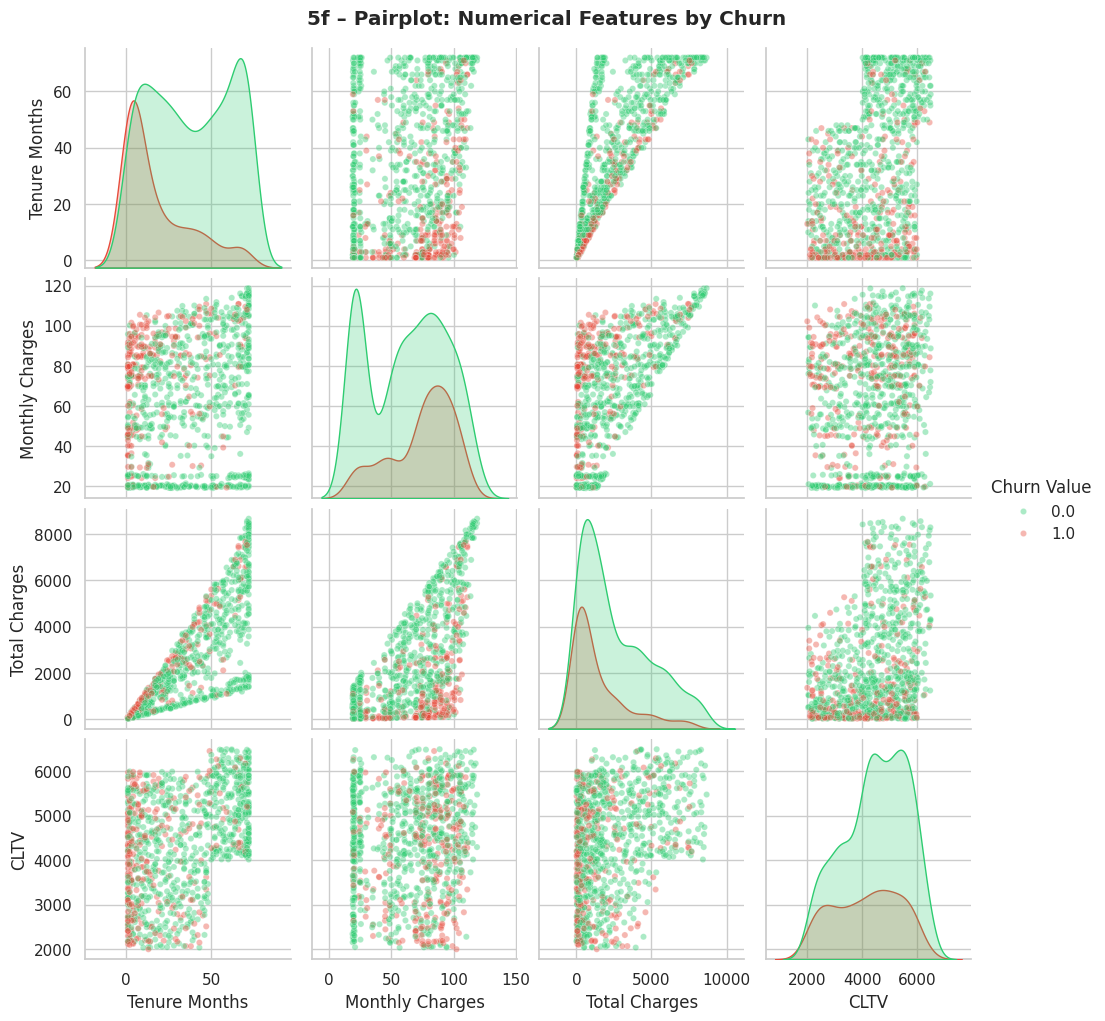

In [ ]:
pair_cols  = [c for c in continuous_cols if c in df.columns] + ['Churn Value']
pp_sample  = df[pair_cols].sample(min(1000, len(df)), random_state=42)
pp = sns.pairplot(pp_sample, hue='Churn Value', diag_kind='kde',
                  palette={0: '#2ecc71', 1: '#e74c3c'},
                  plot_kws={'alpha': 0.4, 's': 20})
pp.fig.suptitle('5f – Pairplot: Numerical Features by Churn', y=1.02, fontweight='bold')
plt.show()

5g. Geographic churn heatmap (Folium)

In [ ]:
if FOLIUM_AVAILABLE and 'Latitude' in df.columns and 'Longitude' in df.columns:
    churned_df = df[df['Churn Value'] == 1][['Latitude', 'Longitude']].dropna()
    m = folium.Map(location=[df['Latitude'].mean(), df['Longitude'].mean()],
                   zoom_start=10, tiles='CartoDB positron')
    HeatMap(churned_df.values.tolist(), radius=10, blur=15).add_to(m)
    m.save('/content/churn_geographic_heatmap.html')
    print("Saved: /content/churn_geographic_heatmap.html")
else:
    print("5g – Geographic heatmap skipped (folium unavailable or lat/long missing).")

Saved: /content/churn_geographic_heatmap.html


SECTION 6 – FEATURE ENCODING (3-TIER STRATEGY)

In [ ]:
df_enc     = df.copy()
target_col = 'Churn Value'

# Drop geographic columns – EDA only, not model features
geo_cols = [c for c in ['Latitude', 'Longitude', 'Lat Long',
                         'Zip Code', 'City', 'State', 'Country']
            if c in df_enc.columns]
df_enc.drop(columns=geo_cols, inplace=True, errors='ignore')
print(f"Dropped geographic columns (EDA-only): {geo_cols}")

# TIER 1 – Binary mapping (Yes/No → 1/0)
binary_maps = {
    'Gender'            : {'Male': 1, 'Female': 0},
    'Senior Citizen'    : {'Yes': 1, 'No': 0},
    'Partner'           : {'Yes': 1, 'No': 0},
    'Dependents'        : {'Yes': 1, 'No': 0},
    'Phone Service'     : {'Yes': 1, 'No': 0},
    'Paperless Billing' : {'Yes': 1, 'No': 0},
    'Multiple Lines'    : {'Yes': 1, 'No': 0, 'No phone service': 0},
    'Online Security'   : {'Yes': 1, 'No': 0, 'No internet service': 0},
    'Online Backup'     : {'Yes': 1, 'No': 0, 'No internet service': 0},
    'Device Protection' : {'Yes': 1, 'No': 0, 'No internet service': 0},
    'Tech Support'      : {'Yes': 1, 'No': 0, 'No internet service': 0},
    'Streaming TV'      : {'Yes': 1, 'No': 0, 'No internet service': 0},
    'Streaming Movies'  : {'Yes': 1, 'No': 0, 'No internet service': 0},
}

for col, mapping in binary_maps.items():
    if col in df_enc.columns:
        df_enc[col] = df_enc[col].map(mapping).fillna(0).astype(int)

# TIER 2 – One-Hot Encoding for low-cardinality nominals (≤ 5 unique values)
remaining_obj = df_enc.select_dtypes(include='object').columns.tolist()
low_card      = [c for c in remaining_obj
                 if df_enc[c].nunique() <= 5 and c != target_col]
if low_card:
    df_enc = pd.get_dummies(df_enc, columns=low_card, drop_first=True, dtype=int)
    print(f"One-Hot Encoded: {low_card}")

# TIER 3 – Target Encoding for high-cardinality nominals (> 5 unique values)
remaining_obj2 = df_enc.select_dtypes(include='object').columns.tolist()
high_card      = [c for c in remaining_obj2 if c != target_col]
for col in high_card:
    enc_map      = df_enc.groupby(col)[target_col].mean()
    df_enc[col]  = df_enc[col].map(enc_map)
    print(f"Target-Encoded: '{col}'")

print(f"\nEncoded shape: {df_enc.shape}")


Dropped geographic columns (EDA-only): ['Latitude', 'Longitude', 'Lat Long', 'Zip Code', 'City', 'State', 'Country']
One-Hot Encoded: ['Internet Service', 'Contract', 'Payment Method']

Encoded shape: (7043, 25)


 SECTION 7 – FEATURE SELECTION (SelectKBest chi-squared)


Top 20 features by chi-squared score:
                               Feature    Chi2 Score
                         Total Charges 627340.305176
                                  CLTV  36391.048522
                         Tenure Months  16278.923685
                       Monthly Charges   3680.787699
                     Contract_Two year    488.578090
       Payment Method_Electronic check    426.422767
          Internet Service_Fiber optic    374.476216
                            Dependents    334.563859
                   Internet Service_No    286.520193
                     Contract_One year    176.123171
                       Online Security    147.295858
                          Tech Support    135.559783
                        Senior Citizen    134.351545
                     Paperless Billing    105.680863
Payment Method_Credit card (automatic)     99.582057
                               Partner     82.412083
           Payment Method_Mailed check     45.651590
       

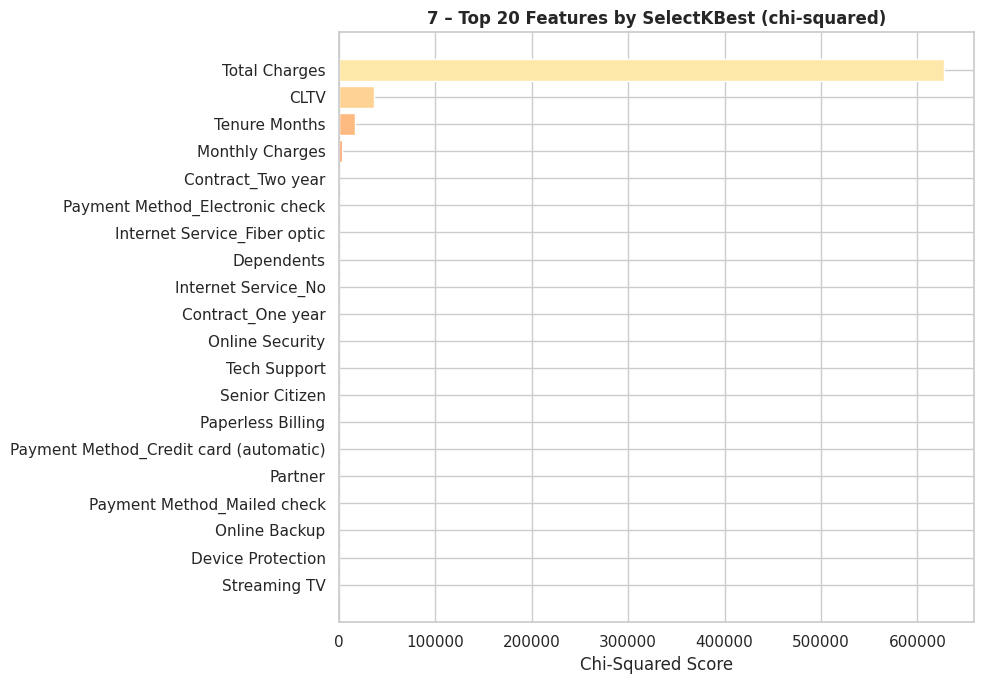


Feature matrix after selection: (7043, 20)


In [ ]:
X_raw = df_enc.drop(columns=[target_col])
y_raw = df_enc[target_col]

# Clip negatives introduced by target encoding before chi-squared test
X_clipped = np.clip(X_raw.values, 0, None)

K        = min(20, X_raw.shape[1])
selector = SelectKBest(score_func=chi2, k=K)
selector.fit(X_clipped, y_raw)

feature_scores = pd.DataFrame({
    'Feature'    : X_raw.columns,
    'Chi2 Score' : selector.scores_
}).sort_values('Chi2 Score', ascending=False)

print(f"\nTop {K} features by chi-squared score:")
print(feature_scores.head(K).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 7))
top_feat = feature_scores.head(K)
ax.barh(top_feat['Feature'][::-1], top_feat['Chi2 Score'][::-1],
        color=sns.color_palette('magma', K))
ax.set_xlabel('Chi-Squared Score')
ax.set_title(f'7 – Top {K} Features by SelectKBest (chi-squared)', fontweight='bold')
plt.tight_layout()
plt.show()

selected_features = feature_scores.head(K)['Feature'].tolist()
X_selected        = X_raw[selected_features]
y_selected        = y_raw.copy()
print(f"\nFeature matrix after selection: {X_selected.shape}")

SECTION 8 – CLASS BALANCING WITH SMOTE + BEFORE/AFTER VISUALISATION

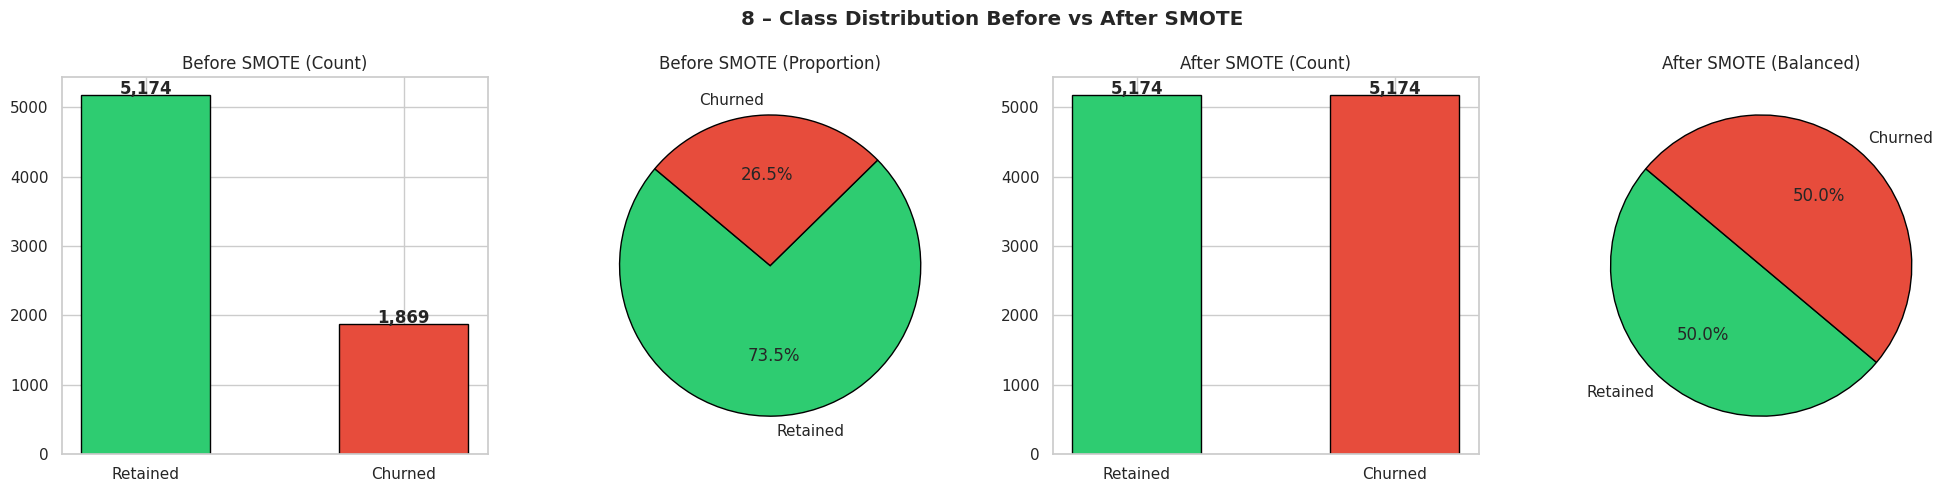

Before SMOTE: {0.0: np.int64(5174), 1.0: np.int64(1869)}
After  SMOTE: {0.0: np.int64(5174), 1.0: np.int64(5174)}
Balanced shape: (10348, 20)


In [ ]:
pre_counts              = y_selected.value_counts().sort_index()
smote                   = SMOTE(random_state=42, k_neighbors=5)
X_balanced, y_balanced  = smote.fit_resample(X_selected, y_selected)
post_counts             = pd.Series(y_balanced).value_counts().sort_index()

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle('8 – Class Distribution Before vs After SMOTE', fontweight='bold')
colours = ['#2ecc71', '#e74c3c']
labels_pie = ['Retained', 'Churned']

axes[0].bar(labels_pie, pre_counts.values, color=colours, edgecolor='black', width=0.5)
axes[0].set_title('Before SMOTE (Count)')
for i, v in enumerate(pre_counts.values):
    axes[0].text(i, v + 20, f'{v:,}', ha='center', fontweight='bold')

axes[1].pie(pre_counts.values, labels=labels_pie, autopct='%1.1f%%',
            colors=colours, startangle=140, wedgeprops={'edgecolor': 'black'})
axes[1].set_title('Before SMOTE (Proportion)')

axes[2].bar(labels_pie, post_counts.values, color=colours, edgecolor='black', width=0.5)
axes[2].set_title('After SMOTE (Count)')
for i, v in enumerate(post_counts.values):
    axes[2].text(i, v + 20, f'{v:,}', ha='center', fontweight='bold')

axes[3].pie(post_counts.values, labels=labels_pie, autopct='%1.1f%%',
            colors=colours, startangle=140, wedgeprops={'edgecolor': 'black'})
axes[3].set_title('After SMOTE (Balanced)')

plt.tight_layout()
plt.show()

print(f"Before SMOTE: {dict(pre_counts)}")
print(f"After  SMOTE: {dict(post_counts)}")
print(f"Balanced shape: {X_balanced.shape}")


SECTION 9 – TRAIN / TEST SPLIT & FEATURE SCALING

In [ ]:
# 80/20 stratified split – preserves class ratio in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X_balanced, y_balanced,
    test_size=0.2, random_state=42, stratify=y_balanced
)

# StandardScaler fitted on train only – applied to test without re-fitting
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Train shape : {X_train_sc.shape}")
print(f"Test  shape : {X_test_sc.shape}")

Train shape : (8278, 20)
Test  shape : (2070, 20)


In [ ]:
# Champion selected by highest ROC-AUC (not accuracy)
classical_models = {
    'Extra Trees'       : ExtraTreesClassifier(n_estimators=100, random_state=42),
    'Random Forest'     : RandomForestClassifier(n_estimators=100, random_state=42),
    'Bagging'           : BaggingClassifier(random_state=42),
    'Decision Tree'     : DecisionTreeClassifier(max_depth=20, random_state=42),
    'Gradient Boosting' : GradientBoostingClassifier(n_estimators=100, random_state=42),
    'XGBoost'           : XGBClassifier(n_estimators=100, random_state=42,
                                        eval_metric='logloss',
                                        use_label_encoder=False),
    'LightGBM'          : LGBMClassifier(n_estimators=100, random_state=42, verbose=-1),
}

results = {}


───────────────────────────────────────────────────────
Model     : Extra Trees
Accuracy  : 84.30%   |   ROC-AUC: 0.9238

Classification Report:
              precision    recall  f1-score   support

    Retained       0.85      0.83      0.84      1035
     Churned       0.83      0.86      0.85      1035

    accuracy                           0.84      2070
   macro avg       0.84      0.84      0.84      2070
weighted avg       0.84      0.84      0.84      2070


───────────────────────────────────────────────────────
Model     : Random Forest
Accuracy  : 85.85%   |   ROC-AUC: 0.9325

Classification Report:
              precision    recall  f1-score   support

    Retained       0.87      0.84      0.86      1035
     Churned       0.85      0.87      0.86      1035

    accuracy                           0.86      2070
   macro avg       0.86      0.86      0.86      2070
weighted avg       0.86      0.86      0.86      2070


───────────────────────────────────────────────────

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [19:45:23] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



───────────────────────────────────────────────────────
Model     : XGBoost
Accuracy  : 85.17%   |   ROC-AUC: 0.9313

Classification Report:
              precision    recall  f1-score   support

    Retained       0.86      0.84      0.85      1035
     Churned       0.84      0.86      0.85      1035

    accuracy                           0.85      2070
   macro avg       0.85      0.85      0.85      2070
weighted avg       0.85      0.85      0.85      2070



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



───────────────────────────────────────────────────────
Model     : LightGBM
Accuracy  : 85.99%   |   ROC-AUC: 0.9337

Classification Report:
              precision    recall  f1-score   support

    Retained       0.87      0.85      0.86      1035
     Churned       0.85      0.87      0.86      1035

    accuracy                           0.86      2070
   macro avg       0.86      0.86      0.86      2070
weighted avg       0.86      0.86      0.86      2070



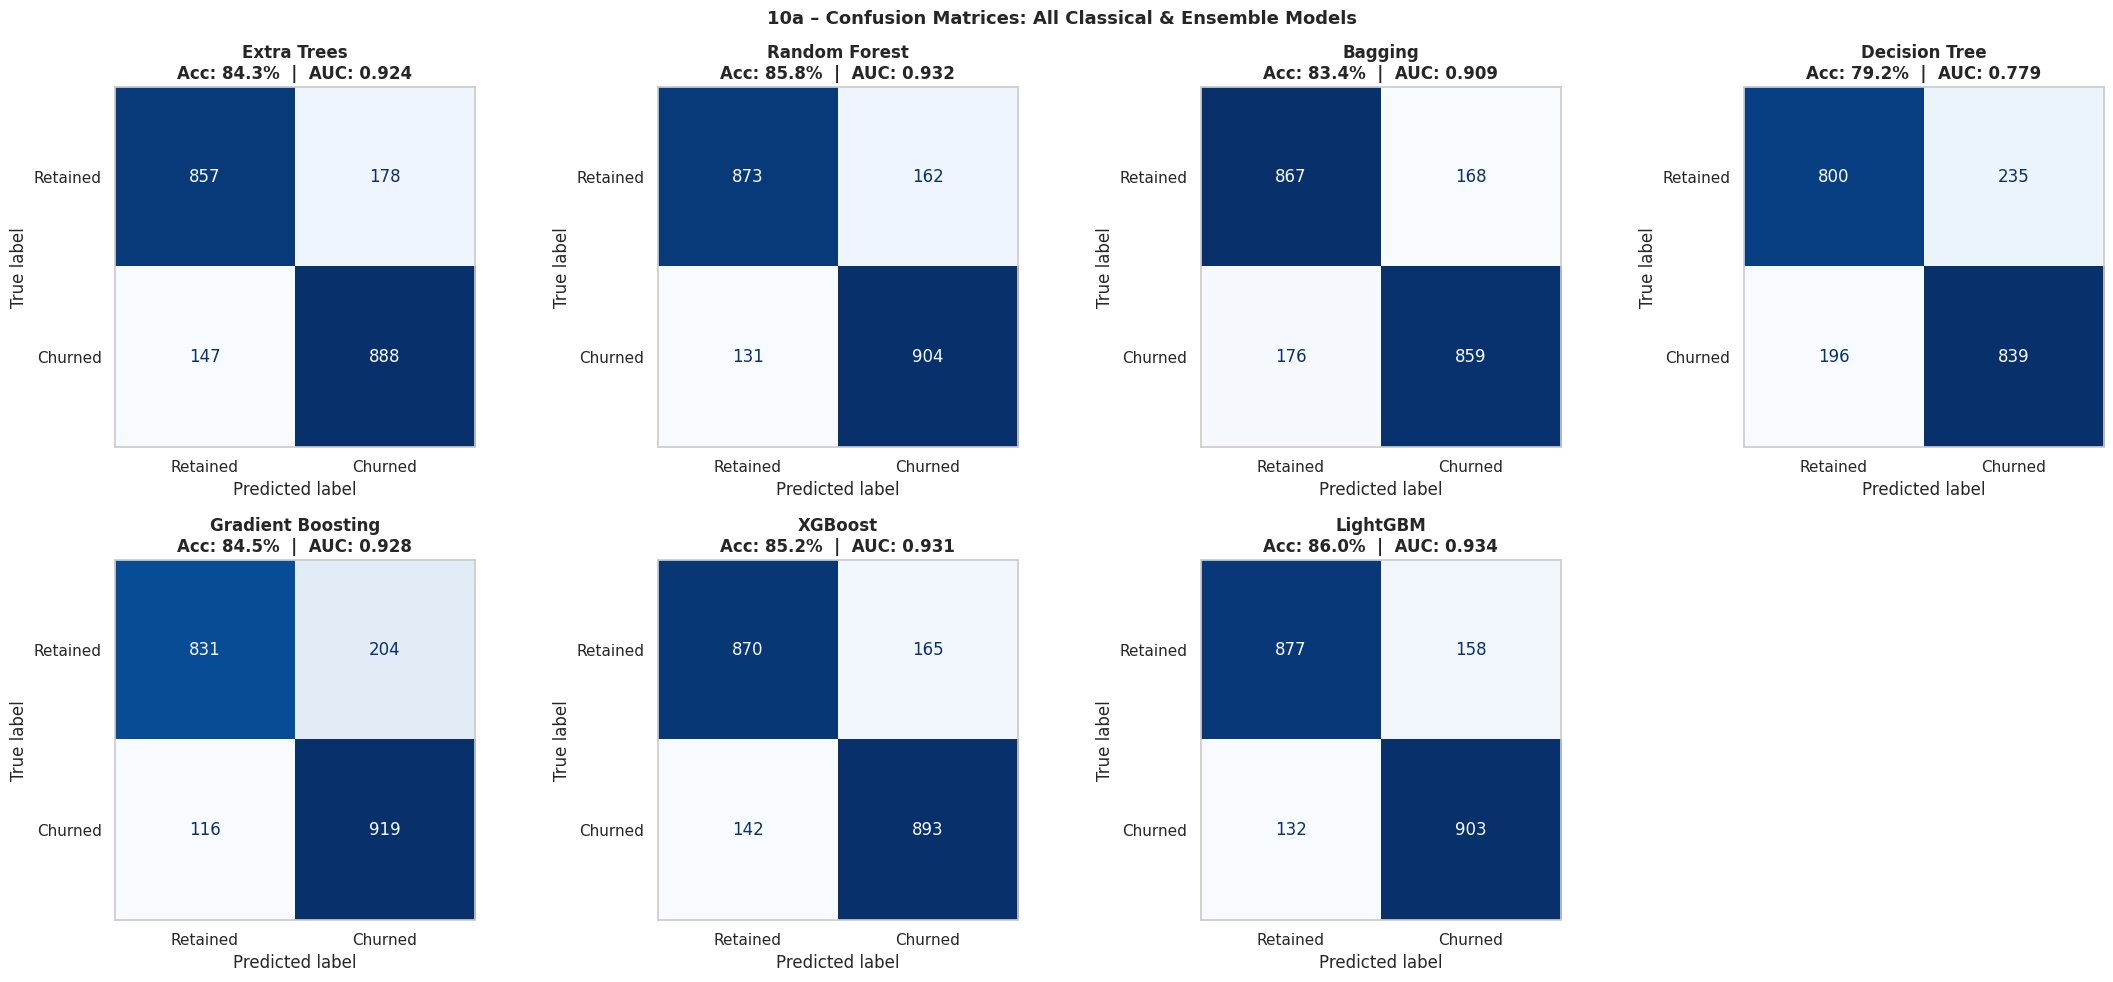

In [ ]:
# Champion selected by highest ROC-AUC (not accuracy)
classical_models = {
    'Extra Trees'       : ExtraTreesClassifier(n_estimators=100, random_state=42),
    'Random Forest'     : RandomForestClassifier(n_estimators=100, random_state=42),
    'Bagging'           : BaggingClassifier(random_state=42),
    'Decision Tree'     : DecisionTreeClassifier(max_depth=20, random_state=42),
    'Gradient Boosting' : GradientBoostingClassifier(n_estimators=100, random_state=42),
    'XGBoost'           : XGBClassifier(n_estimators=100, random_state=42,
                                        eval_metric='logloss',
                                        use_label_encoder=False),
    'LightGBM'          : LGBMClassifier(n_estimators=100, random_state=42, verbose=-1),
}

results = {}

# Confusion matrix grid
fig_cm, axes_cm = plt.subplots(2, 4, figsize=(22, 10))
fig_cm.suptitle('10a – Confusion Matrices: All Classical & Ensemble Models',
                fontsize=13, fontweight='bold')
axes_cm = axes_cm.flatten()

for idx, (name, model) in enumerate(classical_models.items()):
    model.fit(X_train_sc, y_train)
    y_pred = model.predict(X_test_sc)
    y_prob = model.predict_proba(X_test_sc)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    results[name] = {
        'Accuracy' : acc,   'ROC-AUC' : auc,
        'model'    : model, 'y_pred'  : y_pred, 'y_prob': y_prob
    }

    print(f"\n{'─'*55}")
    print(f"Model     : {name}")
    print(f"Accuracy  : {acc*100:.2f}%   |   ROC-AUC: {auc:.4f}")
    print(f"\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['Retained', 'Churned']))

    cm   = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Retained', 'Churned'])
    disp.plot(ax=axes_cm[idx], cmap='Blues', values_format='d', colorbar=False)
    axes_cm[idx].set_title(f"{name}\nAcc: {acc*100:.1f}%  |  AUC: {auc:.3f}",
                           fontweight='bold')
    axes_cm[idx].grid(False)

for j in range(len(classical_models), len(axes_cm)):
    axes_cm[j].set_visible(False)

plt.tight_layout()
plt.show()


SECTION 11 – ARTIFICIAL NEURAL NETWORK (ANN)

In [ ]:
# Architecture: Dense → BatchNorm → Dropout → Dense → BatchNorm → Dropout → Output
ann_model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_sc.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

ann_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

ann_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,841 (15.00 KB)

 Trainable params: 3,649 (14.25 KB)

 Non-trainable params: 192 (768.00 B)


Training ANN...

Epoch 1/100
220/220 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.7814 - loss: 0.4744 - val_accuracy: 0.8253 - val_loss: 0.3914
Epoch 2/100
220/220 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8168 - loss: 0.4155 - val_accuracy: 0.8293 - val_loss: 0.3745
Epoch 3/100
220/220 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8204 - loss: 0.4050 - val_accuracy: 0.8317 - val_loss: 0.3736
Epoch 4/100
220/220 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8263 - loss: 0.3915 - val_accuracy: 0.8341 - val_loss: 0.3700
Epoch 5/100
220/220 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8260 - loss: 0.3857 - val_accuracy: 0.8357 - val_loss: 0.3679
Epoch 6/100
220/220 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8321 - loss: 0.3766 - val_accuracy: 0.8374 - val_loss: 0.3658
Epoch 7/100
220/220 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8304 - loss: 0.3772 - val_accuracy: 0.8382 - val_loss: 0.3632
Epoch 8/100
220/220 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8360 - loss:

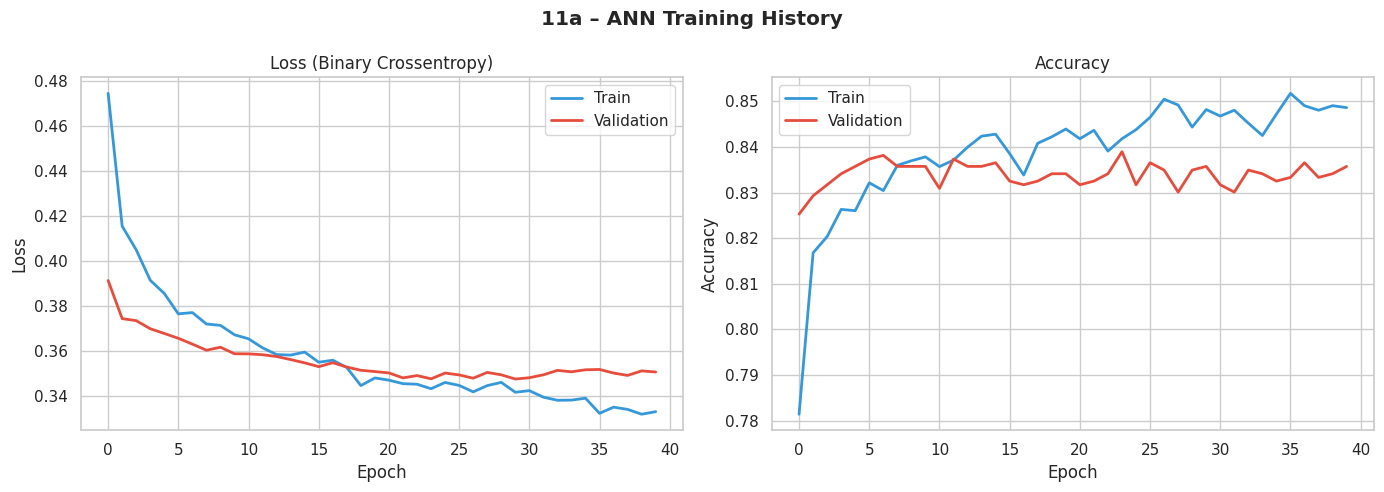

In [ ]:
# Early stopping – halts training if val_loss does not improve for 10 epochs
early_stop = EarlyStopping(monitor='val_loss', patience=10,
                            restore_best_weights=True, verbose=1)

print("\nTraining ANN...\n")
history = ann_model.fit(
    X_train_sc, y_train,
    epochs=100, batch_size=32,
    validation_split=0.15,
    callbacks=[early_stop],
    verbose=1
)

# ANN training history plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('11a – ANN Training History', fontweight='bold')

axes[0].plot(history.history['loss'],     color='#3498db', lw=2, label='Train')
axes[0].plot(history.history['val_loss'], color='#e74c3c', lw=2, label='Validation')
axes[0].set_title('Loss (Binary Crossentropy)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history.history['accuracy'],     color='#3498db', lw=2, label='Train')
axes[1].plot(history.history['val_accuracy'], color='#e74c3c', lw=2, label='Validation')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()

65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

ANN — Accuracy: 84.83%   |   ROC-AUC: 0.9271

ANN Classification Report:
              precision    recall  f1-score   support

    Retained       0.87      0.82      0.84      1035
     Churned       0.83      0.88      0.85      1035

    accuracy                           0.85      2070
   macro avg       0.85      0.85      0.85      2070
weighted avg       0.85      0.85      0.85      2070



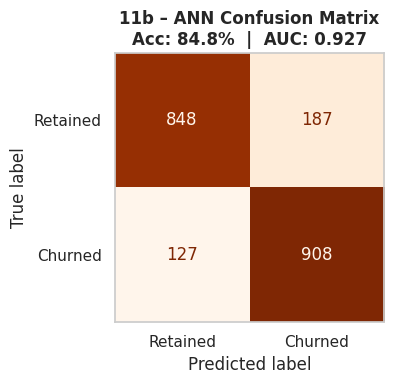

In [ ]:
# ANN evaluation
ann_prob = ann_model.predict(X_test_sc).flatten()
ann_pred = (ann_prob >= 0.5).astype(int)
ann_acc  = accuracy_score(y_test, ann_pred)
ann_auc  = roc_auc_score(y_test, ann_prob)

results['ANN'] = {
    'Accuracy' : ann_acc,   'ROC-AUC' : ann_auc,
    'model'    : ann_model, 'y_pred'  : ann_pred, 'y_prob': ann_prob
}

print(f"\nANN — Accuracy: {ann_acc*100:.2f}%   |   ROC-AUC: {ann_auc:.4f}")
print("\nANN Classification Report:")
print(classification_report(y_test, ann_pred, target_names=['Retained', 'Churned']))

# ANN confusion matrix
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix(y_test, ann_pred),
                       display_labels=['Retained', 'Churned'])\
    .plot(ax=ax, cmap='Oranges', values_format='d', colorbar=False)
ax.set_title(f'11b – ANN Confusion Matrix\nAcc: {ann_acc*100:.1f}%  |  AUC: {ann_auc:.3f}',
             fontweight='bold')
ax.grid(False)
plt.tight_layout()
plt.show()

SECTION 12 – LEARNING CURVES (TRAIN vs VALIDATION AUC)

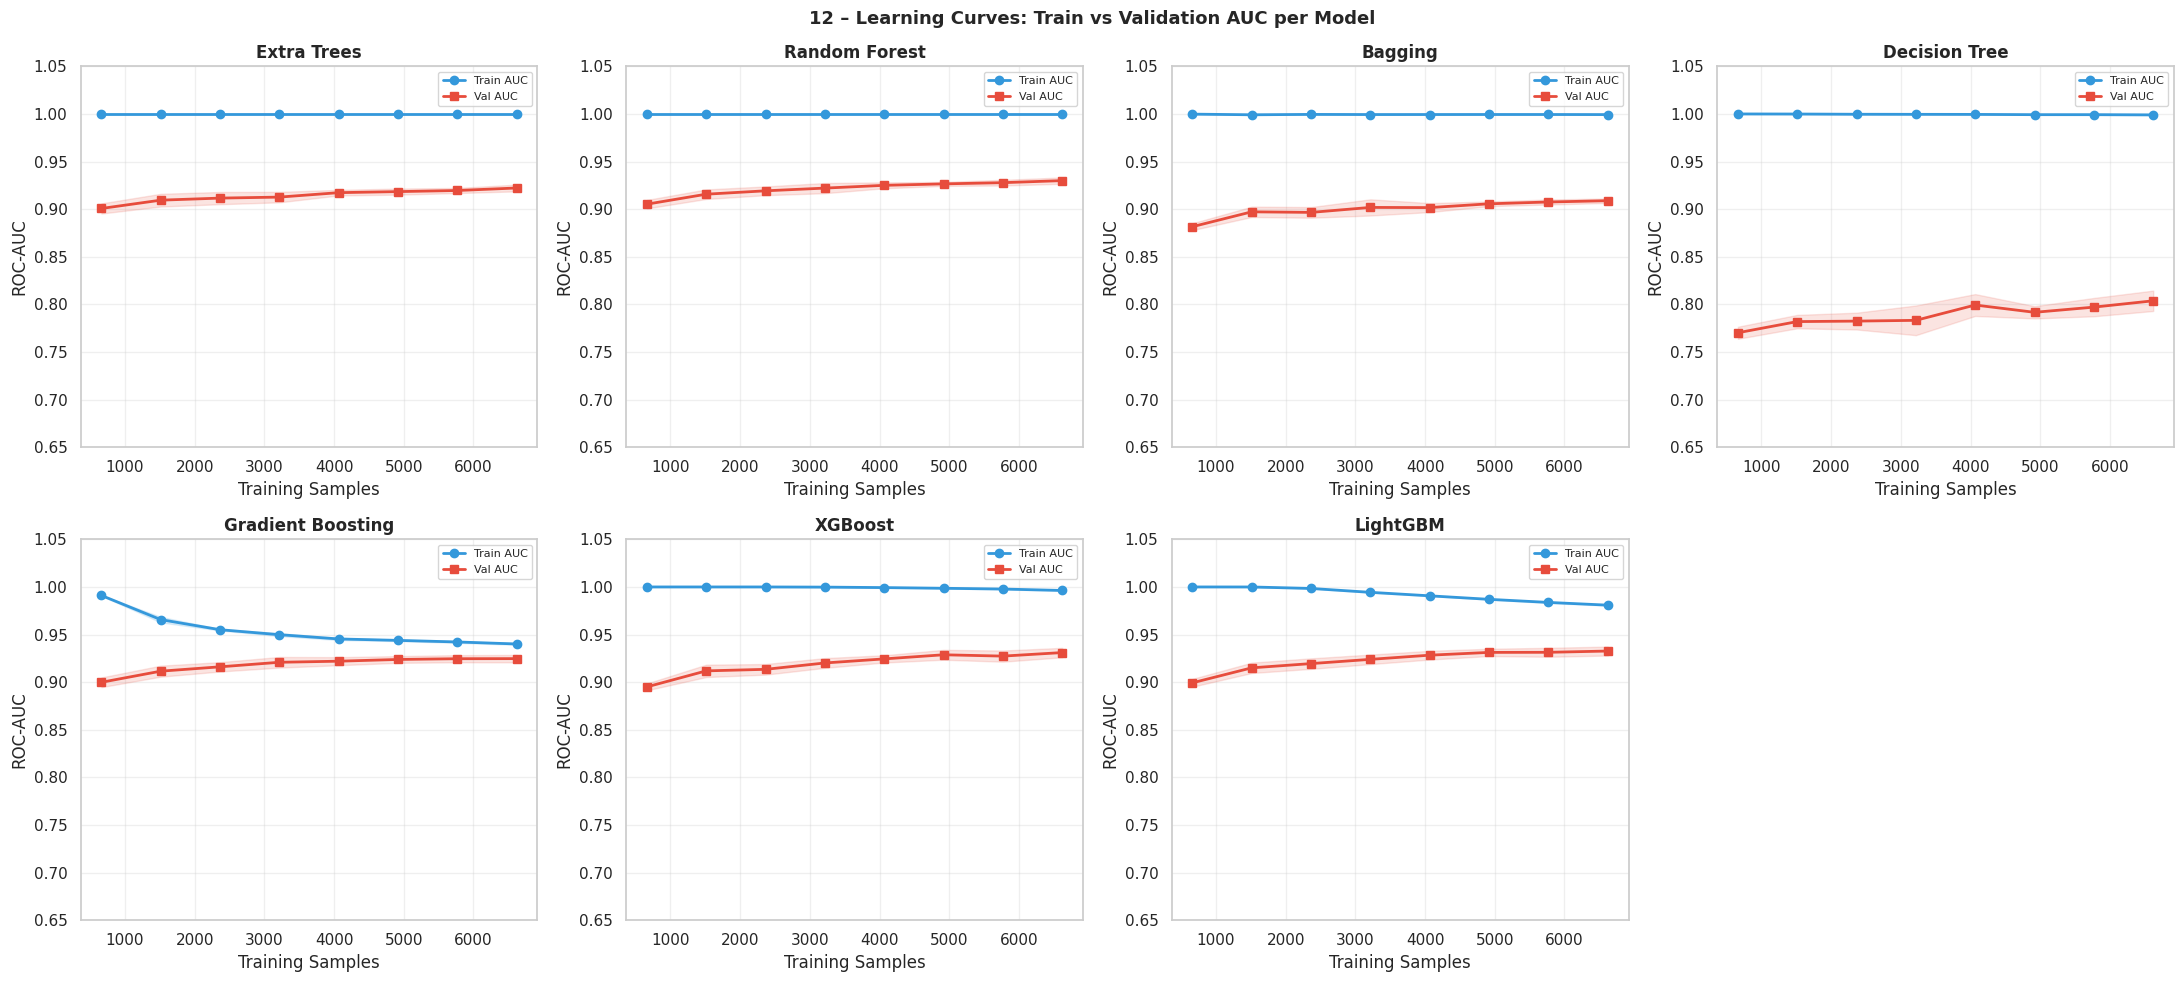

In [ ]:
# Learning curves applied to classical models only (ANN covered by training history)
fig_lc, axes_lc = plt.subplots(2, 4, figsize=(22, 10))
fig_lc.suptitle('12 – Learning Curves: Train vs Validation AUC per Model',
                fontsize=13, fontweight='bold')
axes_lc = axes_lc.flatten()

for idx, (name, model) in enumerate(classical_models.items()):
    train_sz, tr_sc, va_sc = learning_curve(
        model, X_train_sc, y_train,
        train_sizes=np.linspace(0.1, 1.0, 8),
        cv=5, scoring='roc_auc', n_jobs=-1
    )
    tr_mean, tr_std = tr_sc.mean(axis=1), tr_sc.std(axis=1)
    va_mean, va_std = va_sc.mean(axis=1), va_sc.std(axis=1)

    ax = axes_lc[idx]
    ax.plot(train_sz, tr_mean, 'o-', color='#3498db', lw=2, label='Train AUC')
    ax.fill_between(train_sz, tr_mean - tr_std, tr_mean + tr_std, alpha=0.15, color='#3498db')
    ax.plot(train_sz, va_mean, 's-', color='#e74c3c', lw=2, label='Val AUC')
    ax.fill_between(train_sz, va_mean - va_std, va_mean + va_std, alpha=0.15, color='#e74c3c')
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('Training Samples')
    ax.set_ylabel('ROC-AUC')
    ax.legend(fontsize=8)
    ax.set_ylim([0.65, 1.05])
    ax.grid(True, alpha=0.3)

for j in range(len(classical_models), len(axes_lc)):
    axes_lc[j].set_visible(False)

plt.tight_layout()
plt.show()

SECTION 13 – ROC CURVE OVERLAY (ALL 8 MODELS)


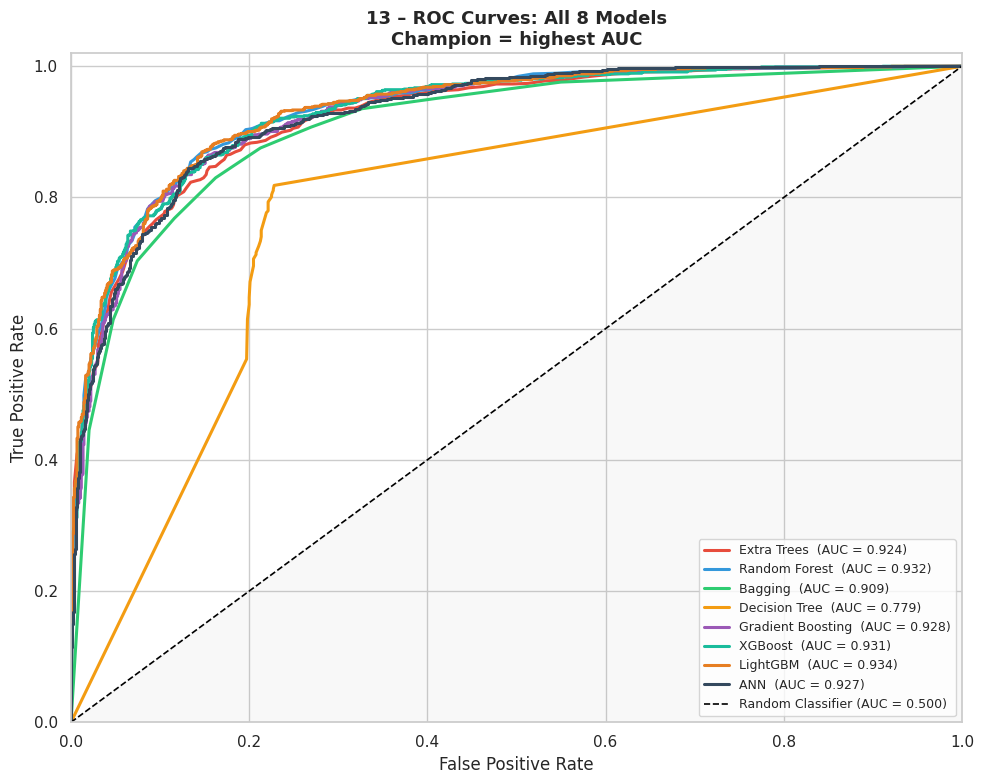

In [ ]:
colours_roc = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12',
               '#9b59b6', '#1abc9c', '#e67e22', '#34495e']

fig, ax = plt.subplots(figsize=(10, 8))

for (name, res), colour in zip(results.items(), colours_roc):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    ax.plot(fpr, tpr, lw=2.2, color=colour,
            label=f"{name}  (AUC = {res['ROC-AUC']:.3f})")

ax.plot([0, 1], [0, 1], 'k--', lw=1.2, label='Random Classifier (AUC = 0.500)')
ax.fill_between([0, 1], [0, 1], alpha=0.05, color='grey')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('13 – ROC Curves: All 8 Models\nChampion = highest AUC',
             fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.show()



 SECTION 14 – MODEL COMPARISON SUMMARY TABLE & BAR CHART


  MODEL COMPARISON TABLE (sorted by ROC-AUC)
Rank  Model                  Accuracy (%)   ROC-AUC
--------------------------------------------------
1     LightGBM                      85.99    0.9337
2     Random Forest                 85.85    0.9325
3     XGBoost                       85.17    0.9313
4     Gradient Boosting             84.54    0.9284
5     ANN                           84.83    0.9271
6     Extra Trees                   84.30    0.9238
7     Bagging                       83.38    0.9086
8     Decision Tree                 79.18    0.7791


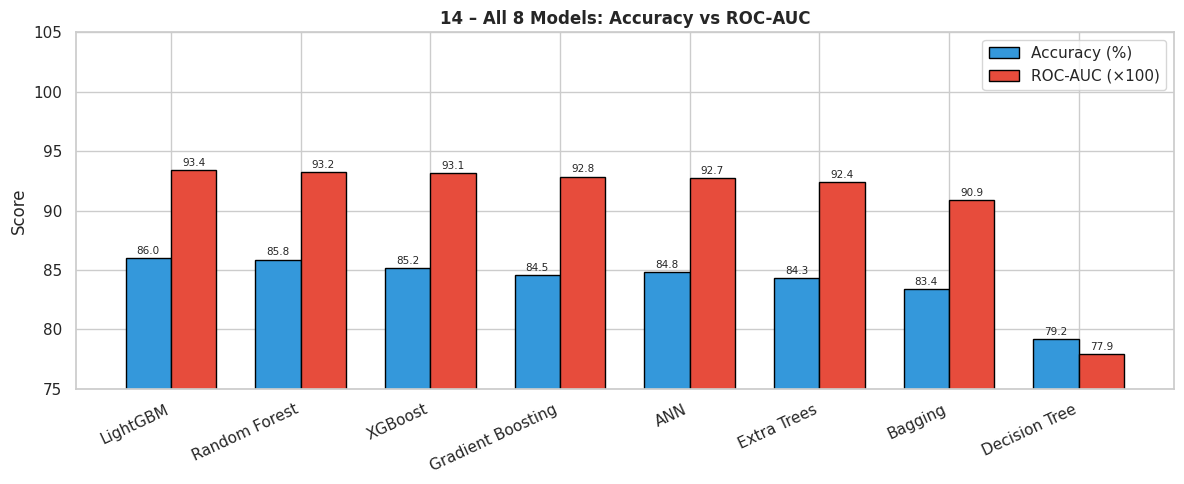

In [ ]:
results_df = pd.DataFrame({
    'Model'    : list(results.keys()),
    'Accuracy' : [r['Accuracy'] * 100 for r in results.values()],
    'ROC-AUC'  : [r['ROC-AUC']        for r in results.values()]
}).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)

print("\n" + "=" * 55)
print("  MODEL COMPARISON TABLE (sorted by ROC-AUC)")
print("=" * 55)
print(f"{'Rank':<5} {'Model':<22} {'Accuracy (%)':>12} {'ROC-AUC':>9}")
print("-" * 50)
for i, row in results_df.iterrows():
    print(f"{i+1:<5} {row['Model']:<22} {row['Accuracy']:>12.2f} {row['ROC-AUC']:>9.4f}")

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(results_df))
w = 0.35

bars1 = ax.bar(x - w/2, results_df['Accuracy'],
               w, label='Accuracy (%)', color='#3498db', edgecolor='black')
bars2 = ax.bar(x + w/2, results_df['ROC-AUC'] * 100,
               w, label='ROC-AUC (×100)', color='#e74c3c', edgecolor='black')

ax.set_xticks(x)
ax.set_xticklabels(results_df['Model'], rotation=25, ha='right')
ax.set_ylabel('Score')
ax.set_title('14 – All 8 Models: Accuracy vs ROC-AUC', fontweight='bold')
ax.legend()
ax.set_ylim([75, 105])

for bar in list(bars1) + list(bars2):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2., h + 0.2,
            f'{h:.1f}', ha='center', va='bottom', fontsize=7.5)

plt.tight_layout()
plt.show()

 SECTION 15 – CHAMPION MODEL SUMMARY & FEATURE IMPORTANCE


  CHAMPION MODEL : LightGBM
  Accuracy       : 85.99%
  ROC-AUC        : 0.9337

Classification Report:
              precision    recall  f1-score   support

    Retained       0.87      0.85      0.86      1035
     Churned       0.85      0.87      0.86      1035

    accuracy                           0.86      2070
   macro avg       0.86      0.86      0.86      2070
weighted avg       0.86      0.86      0.86      2070



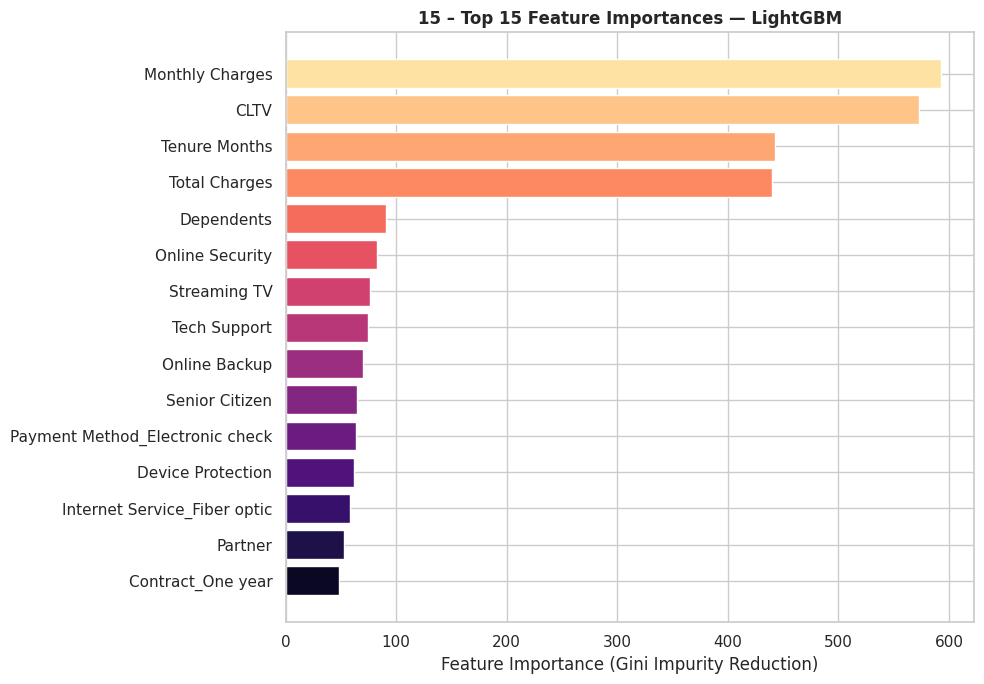


Pipeline complete. Champion: LightGBM | AUC: 0.9337 | Accuracy: 85.99%


In [ ]:

# Champion selected by highest Test ROC-AUC
champion_name = max(results, key=lambda k: results[k]['ROC-AUC'])
champion      = results[champion_name]

print(f"\n{'='*55}")
print(f"  CHAMPION MODEL : {champion_name}")
print(f"  Accuracy       : {champion['Accuracy']*100:.2f}%")
print(f"  ROC-AUC        : {champion['ROC-AUC']:.4f}")
print(f"{'='*55}")
print("\nClassification Report:")
print(classification_report(y_test, champion['y_pred'],
                             target_names=['Retained', 'Churned']))

# Feature importance (available for tree-based models only)
champ_model = champion['model']
if hasattr(champ_model, 'feature_importances_'):
    fi = pd.DataFrame({
        'Feature'    : selected_features,
        'Importance' : champ_model.feature_importances_
    }).sort_values('Importance', ascending=False).head(15)

    fig, ax = plt.subplots(figsize=(10, 7))
    ax.barh(fi['Feature'][::-1], fi['Importance'][::-1],
            color=sns.color_palette('magma', len(fi)))
    ax.set_xlabel('Feature Importance (Gini Impurity Reduction)')
    ax.set_title(f'15 – Top 15 Feature Importances — {champion_name}',
                 fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("ANN selected as champion — feature importance via SHAP values recommended.")

print(f"\nPipeline complete. Champion: {champion_name} | "
      f"AUC: {champion['ROC-AUC']:.4f} | "
      f"Accuracy: {champion['Accuracy']*100:.2f}%")